¡Hola, Fercho!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:











<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
Se realizaron los cambios solicitados.
</div>


# Proyecto de pruebas A/B

## 1. Objetivo del Proyecto

Propósito de la prueba: probar cambios relacionados con la introducción de un sistema de recomendaciones mejorado.

Dentro de los 14 días posteriores a la inscripción, los usuarios mostrarán una mejor conversión en vistas de la página del producto (el evento product_page), instancias de agregar artículos al carrito de compras (product_cart) y compras (purchase). En cada etapa del embudo product_page → product_cart → purchase, habrá al menos un 10% de aumento.

## 2. Descripción técnica
Nombre de la prueba: recommender_system_test

Grupos: А (control), B (nuevo embudo de pago)

Fecha de lanzamiento: 2020-12-07

Fecha en la que dejaron de aceptar nuevos usuarios: 2020-12-21

Fecha de finalización: 2021-01-01

Audiencia: 15% de los nuevos usuarios de la región de la UE

## 3. Plan de trabajo 

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import norm

In [30]:
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

### Explorar datos.

In [5]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


In [6]:
print(marketing.head())

                           name                   regions    start_dt  \
0      Christmas&New Year Promo             EU, N.America  2020-12-25   
1  St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2        St. Patric's Day Promo             EU, N.America  2020-03-17   
3                  Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4             4th of July Promo                 N.America  2020-07-04   

    finish_dt  
0  2021-01-03  
1  2020-02-16  
2  2020-03-19  
3  2020-04-19  
4  2020-07-11  


In [31]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

In [13]:
print(marketing.dtypes)
print(marketing.head())

name                 object
regions              object
start_dt     datetime64[ns]
finish_dt    datetime64[ns]
dtype: object
                           name                   regions   start_dt  \
0      Christmas&New Year Promo             EU, N.America 2020-12-25   
1  St. Valentine's Day Giveaway  EU, CIS, APAC, N.America 2020-02-14   
2        St. Patric's Day Promo             EU, N.America 2020-03-17   
3                  Easter Promo  EU, CIS, APAC, N.America 2020-04-12   
4             4th of July Promo                 N.America 2020-07-04   

   finish_dt  
0 2021-01-03  
1 2020-02-16  
2 2020-03-19  
3 2020-04-19  
4 2020-07-11  


In [14]:
new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [15]:
print(new_users.head())

            user_id  first_date     region   device
0  D72A72121175D8BE  2020-12-07         EU       PC
1  F1C668619DFE6E65  2020-12-07  N.America  Android
2  2E1BF1D4C37EA01F  2020-12-07         EU       PC
3  50734A22C0C63768  2020-12-07         EU   iPhone
4  E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone


In [32]:
new_users['first_date'] = pd.to_datetime(new_users['first_date'])

In [18]:
print(new_users.dtypes)
print(new_users.head())

user_id               object
first_date    datetime64[ns]
region                object
device                object
dtype: object
            user_id first_date     region   device
0  D72A72121175D8BE 2020-12-07         EU       PC
1  F1C668619DFE6E65 2020-12-07  N.America  Android
2  2E1BF1D4C37EA01F 2020-12-07         EU       PC
3  50734A22C0C63768 2020-12-07         EU   iPhone
4  E1BDDCE0DAFA2679 2020-12-07  N.America   iPhone


In [19]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [20]:
print(events.head())

            user_id             event_dt event_name  details
0  E1BDDCE0DAFA2679  2020-12-07 20:22:03   purchase    99.99
1  7B6452F081F49504  2020-12-07 09:22:53   purchase     9.99
2  9CD9F34546DF254C  2020-12-07 12:59:29   purchase     4.99
3  96F27A054B191457  2020-12-07 04:02:40   purchase     4.99
4  1FD7660FDF94CA1F  2020-12-07 10:15:09   purchase     4.99


In [33]:
events['event_dt'] = pd.to_datetime(events['event_dt'])

In [22]:
print(events.dtypes)
print(events.head())

user_id               object
event_dt      datetime64[ns]
event_name            object
details              float64
dtype: object
            user_id            event_dt event_name  details
0  E1BDDCE0DAFA2679 2020-12-07 20:22:03   purchase    99.99
1  7B6452F081F49504 2020-12-07 09:22:53   purchase     9.99
2  9CD9F34546DF254C 2020-12-07 12:59:29   purchase     4.99
3  96F27A054B191457 2020-12-07 04:02:40   purchase     4.99
4  1FD7660FDF94CA1F 2020-12-07 10:15:09   purchase     4.99


In [23]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [24]:
print(participants.head())

            user_id group                  ab_test
0  D1ABA3E2887B6A73     A  recommender_system_test
1  A7A3664BD6242119     A  recommender_system_test
2  DABC14FDDFADD29E     A  recommender_system_test
3  04988C5DF189632E     A  recommender_system_test
4  4FF2998A348C484F     A  recommender_system_test


Después de revisar los datos de los dataframes, tuve que realizar cambios de tipo de object a datetime, ya que esto puede ser necesario para el análisis. Decidí mantener los datos faltantes sin eliminar o cambiarlos, ya que pueden ser útiles más adelante.

### Análisis exploratorio.

##### ¿Qué tipos de eventos únicos tienes? 

In [34]:
print("Tipos de eventos únicos:")
print(events['event_name'].unique())
print(f"\nTotal de tipos de eventos: {events['event_name'].nunique()}")

Tipos de eventos únicos:
['purchase' 'product_cart' 'product_page' 'login']

Total de tipos de eventos: 4


In [35]:
print("Frecuencia de cada tipo de evento:")
event_counts = events['event_name'].value_counts()
print(event_counts)

Frecuencia de cada tipo de evento:
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64


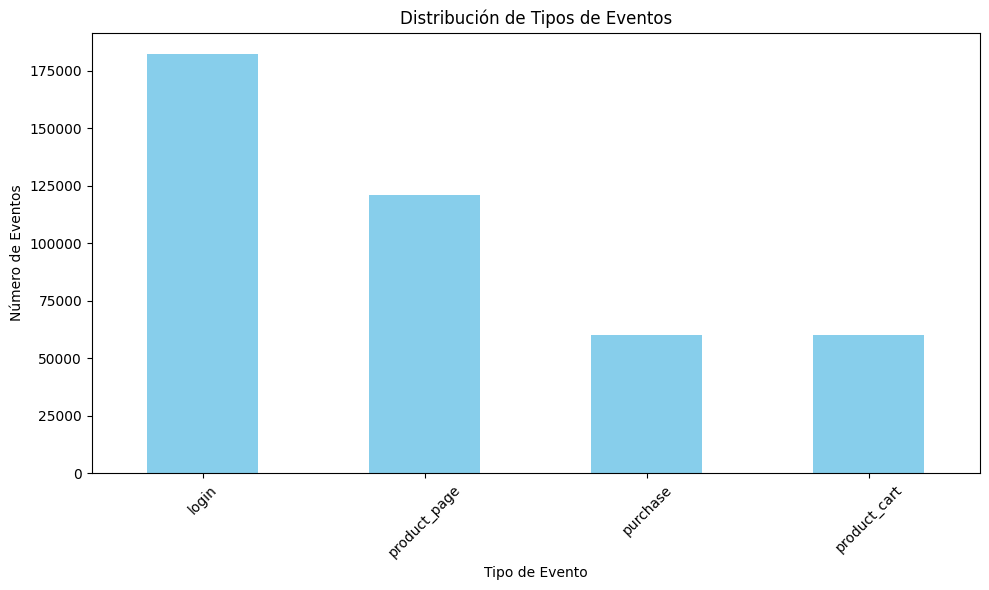

In [36]:
plt.figure(figsize=(10, 6))
event_counts.plot(kind='bar', color='skyblue')
plt.title('Distribución de Tipos de Eventos')
plt.xlabel('Tipo de Evento')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### ¿El número de eventos por usuario está distribuido equitativamente entre las muestras?

In [37]:
events_with_groups = events.merge(participants, on='user_id', how='inner')
print(f"Eventos totales con información de grupo: {len(events_with_groups)}")

Eventos totales con información de grupo: 102838


In [38]:
events_per_user = events_with_groups.groupby(['user_id', 'group']).size().reset_index(name='event_count')
print("Primeras filas de eventos por usuario:")
print(events_per_user.head())

Primeras filas de eventos por usuario:
            user_id group  event_count
0  0002CE61FF2C4011     A           12
1  001064FEAAB631A1     B           12
2  0010A1C096941592     A           12
3  001E72F50D1C48FA     B            6
4  002412F1EB3F6E38     A            6


In [39]:
print("Estadísticas de eventos por usuario por grupo:\n")
stats_by_group = events_per_user.groupby('group')['event_count'].describe()
print(stats_by_group)

Estadísticas de eventos por usuario por grupo:

        count     mean       std  min  25%  50%  75%   max
group                                                     
A      7874.0  7.45555  4.475159  1.0  4.0  6.0  9.0  40.0
B      6205.0  7.11249  4.246201  1.0  4.0  6.0  9.0  36.0


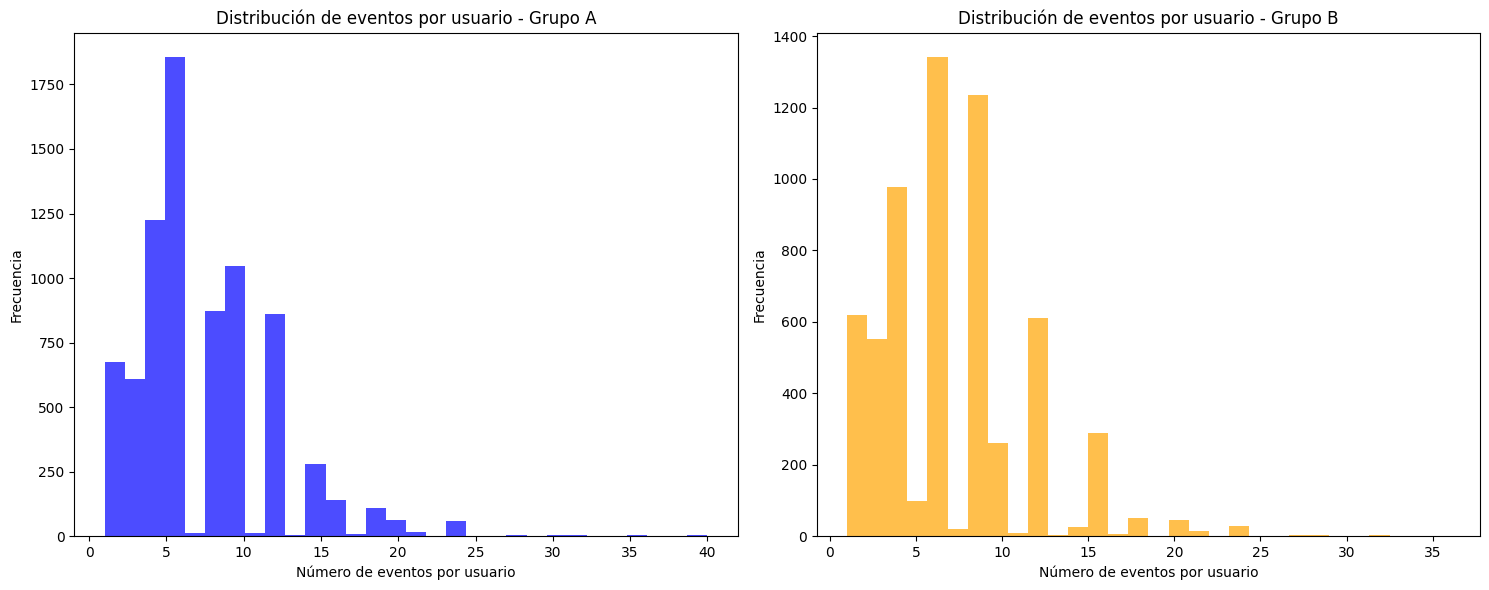

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, group in enumerate(['A', 'B']):
    group_data = events_per_user[events_per_user['group'] == group]['event_count']
    axes[i].hist(group_data, bins=30, alpha=0.7, color=['blue', 'orange'][i])
    axes[i].set_title(f'Distribución de eventos por usuario - Grupo {group}')
    axes[i].set_xlabel('Número de eventos por usuario')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [41]:
avg_events_by_group = events_per_user.groupby('group')['event_count'].mean()
print("Promedio de eventos por usuario por grupo:\n")
print(avg_events_by_group)
print(f"\nDiferencia entre grupos: {avg_events_by_group['B'] - avg_events_by_group['A']:.2f}")

Promedio de eventos por usuario por grupo:

group
A    7.45555
B    7.11249
Name: event_count, dtype: float64

Diferencia entre grupos: -0.34


Despues de verificar la distribucion podemos observar que los dos dos grupos son lo suficiente similares en comportamiento para hacer la comparacion esto nos va a ayudar a realizar nuestra prueba.

##### ¿Hay usuarios que están presentes en ambas muestras?

In [42]:
print("Información básica del DataFrame participants:")
print(f"Total de filas: {len(participants)}")
print(f"Usuarios únicos: {participants['user_id'].nunique()}")
print(f"¿Son iguales? {len(participants) == participants['user_id'].nunique()}")

Información básica del DataFrame participants:
Total de filas: 14525
Usuarios únicos: 13638
¿Son iguales? False


In [43]:
duplicated_users = participants[participants.duplicated('user_id', keep=False)]
print(f"Número de filas con usuarios duplicados: {len(duplicated_users)}")

print("\nPrimeros 10 casos de usuarios duplicados:")
print(duplicated_users.head(10))

user_counts = participants['user_id'].value_counts()
users_with_multiple_entries = user_counts[user_counts > 1]
print(f"\nUsuarios que aparecen más de una vez: {len(users_with_multiple_entries)}")
print(f"Máximo número de apariciones de un usuario: {users_with_multiple_entries.max()}")

Número de filas con usuarios duplicados: 1774

Primeros 10 casos de usuarios duplicados:
             user_id group                  ab_test
2   DABC14FDDFADD29E     A  recommender_system_test
3   04988C5DF189632E     A  recommender_system_test
8   B3A2485649E4A012     A  recommender_system_test
15  EAFB9027A27D510C     B  recommender_system_test
17  5D5E6EE92AF6E9E0     B  recommender_system_test
19  0F1FF07B3788976D     A  recommender_system_test
20  03FBDF999D5B81B8     A  recommender_system_test
22  65F225074FEC2C03     A  recommender_system_test
26  FC3F3E4DA7C85F88     A  recommender_system_test
27  FE2AF0E94DBD470E     A  recommender_system_test

Usuarios que aparecen más de una vez: 887
Máximo número de apariciones de un usuario: 2


In [44]:
print("Análisis de grupos para usuarios duplicados:")

user_groups = participants.groupby('user_id')['group'].unique()
users_in_both_groups = user_groups[user_groups.apply(len) > 1]

print(f"Usuarios que están en AMBOS grupos (A y B): {len(users_in_both_groups)}")

if len(users_in_both_groups) > 0:
    print("\nPrimeros 5 ejemplos de usuarios en ambos grupos:")
    for user_id in users_in_both_groups.head().index:
        user_data = participants[participants['user_id'] == user_id]
        print(f"Usuario {user_id}: grupos {list(user_data['group'].unique())}")

Análisis de grupos para usuarios duplicados:
Usuarios que están en AMBOS grupos (A y B): 441

Primeros 5 ejemplos de usuarios en ambos grupos:
Usuario 0082295A41A867B5: grupos ['A', 'B']
Usuario 00E68F103C66C1F7: grupos ['A', 'B']
Usuario 02313B9E82255F47: grupos ['A', 'B']
Usuario 04F2CF340B4F3822: grupos ['A', 'B']
Usuario 051D59BC38C3B3AA: grupos ['A', 'B']


In [45]:
print("Impacto de los usuarios duplicados:")
print(f"Total de usuarios únicos: {participants['user_id'].nunique()}")
print(f"Usuarios en ambos grupos: {len(users_in_both_groups)}")
print(f"Porcentaje de usuarios afectados: {(len(users_in_both_groups) / participants['user_id'].nunique()) * 100:.2f}%")

print("\nDistribución original:")
print(participants['group'].value_counts())

Impacto de los usuarios duplicados:
Total de usuarios únicos: 13638
Usuarios en ambos grupos: 441
Porcentaje de usuarios afectados: 3.23%

Distribución original:
A    8214
B    6311
Name: group, dtype: int64


In [46]:
def clean_duplicate_users(df):
    """
    Para usuarios duplicados, asigna aleatoriamente a un solo grupo
    """
    df_clean = df.copy()
    
    duplicated_users = df_clean[df_clean.duplicated('user_id', keep=False)]['user_id'].unique()
    
    print(f"Procesando {len(duplicated_users)} usuarios duplicados...")
    
    rows_to_keep = []
    
    for user_id in duplicated_users:
        user_rows = df_clean[df_clean['user_id'] == user_id]
        # Seleccionar aleatoriamente una fila
        random_row = user_rows.sample(n=1, random_state=42)
        rows_to_keep.append(random_row.index[0])
    
    return rows_to_keep

rows_to_keep = clean_duplicate_users(participants)
print(f"Filas seleccionadas aleatoriamente: {len(rows_to_keep)}")

Procesando 887 usuarios duplicados...
Filas seleccionadas aleatoriamente: 887


In [47]:
non_duplicated_users = participants[~participants.duplicated('user_id', keep=False)]

duplicated_selected = participants.loc[rows_to_keep]

participants_clean = pd.concat([non_duplicated_users, duplicated_selected], ignore_index=True)

print(f"DataFrame original: {len(participants)} filas")
print(f"DataFrame limpio: {len(participants_clean)} filas")
print(f"Usuarios únicos en DataFrame limpio: {participants_clean['user_id'].nunique()}")

DataFrame original: 14525 filas
DataFrame limpio: 13638 filas
Usuarios únicos en DataFrame limpio: 13638


In [48]:
print("Verificación de limpieza:")
print(f"¿Hay usuarios duplicados? {participants_clean['user_id'].duplicated().any()}")
print(f"Usuarios únicos = Total de filas? {len(participants_clean) == participants_clean['user_id'].nunique()}")

print("\nNueva distribución de grupos:")
print(participants_clean['group'].value_counts())

Verificación de limpieza:
¿Hay usuarios duplicados? False
Usuarios únicos = Total de filas? True

Nueva distribución de grupos:
A    7549
B    6089
Name: group, dtype: int64


Después de revisar si hay usuarios que estén presentes en ambos grupos, pudimos ver que sí, y decidimos tomar el camino de asignar estas filas de usuarios repetidos a un solo grupo de forma aleatoria para que no haya falla alguna en la prueba.

##### ¿Cómo se distribuye el número de eventos entre los días?

In [49]:
events['date'] = events['event_dt'].dt.date

In [50]:
events_per_day = events['date'].value_counts().sort_index()

print("Primeros 10 días:")
print(events_per_day.head(10))
print(f"\nTotal de días con eventos: {len(events_per_day)}")
print(f"Rango de fechas: {events_per_day.index.min()} a {events_per_day.index.max()}")

Primeros 10 días:
2020-12-07    11385
2020-12-08    12547
2020-12-09    12122
2020-12-10    14077
2020-12-11    13864
2020-12-12    17634
2020-12-13    20985
2020-12-14    26184
2020-12-15    23469
2020-12-16    20909
Name: date, dtype: int64

Total de días con eventos: 23
Rango de fechas: 2020-12-07 a 2020-12-30


In [51]:
print("Estadísticas de eventos por día:")
print(f"Promedio: {events_per_day.mean():.1f} eventos/día")
print(f"Mediana: {events_per_day.median():.1f} eventos/día")
print(f"Mínimo: {events_per_day.min()} eventos/día")
print(f"Máximo: {events_per_day.max()} eventos/día")
print(f"Desviación estándar: {events_per_day.std():.1f}")

Estadísticas de eventos por día:
Promedio: 18424.4 eventos/día
Mediana: 19399.0 eventos/día
Mínimo: 89 eventos/día
Máximo: 32559 eventos/día
Desviación estándar: 7652.0


Después de revisar las estadísticas de eventos por día, podemos observar que hay una gran variabilidad. La diferencia entre el mínimo y el máximo de eventos por día es muy grande, la desviación estándar también es alta y la mediana es ligeramente mayor que el promedio; esto puede sugerir que hay días con menor actividad.

##### ¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?

In [52]:
test_start = pd.to_datetime('2020-12-07')
test_end = pd.to_datetime('2021-01-01')
promo_start = pd.to_datetime('2020-12-25')
promo_end = pd.to_datetime('2021-01-03')

print("Fechas de la prueba A/B:")
print(f"Inicio: {test_start.date()}")
print(f"Fin: {test_end.date()}")
print(f"Duración: {(test_end - test_start).days} días")

print("\nFechas de Christmas&New Year Promo:")
print(f"Inicio: {promo_start.date()}")
print(f"Fin: {promo_end.date()}")

overlap_start = max(test_start, promo_start)
overlap_end = min(test_end, promo_end)
overlap_days = (overlap_end - overlap_start).days

print(f"\nSuperposición: {overlap_days} días ({overlap_start.date()} a {overlap_end.date()})")
print(f"% del período de prueba afectado: {(overlap_days / (test_end - test_start).days) * 100:.1f}%")

Fechas de la prueba A/B:
Inicio: 2020-12-07
Fin: 2021-01-01
Duración: 25 días

Fechas de Christmas&New Year Promo:
Inicio: 2020-12-25
Fin: 2021-01-03

Superposición: 7 días (2020-12-25 a 2021-01-01)
% del período de prueba afectado: 28.0%


In [53]:
print("Regiones disponibles en new_users:")
print(new_users['region'].value_counts())
print(f"\nTotal de usuarios: {len(new_users)}")

participants_with_region = participants_clean.merge(new_users[['user_id', 'region']], on='user_id', how='left')

print("\nDistribución regional en la prueba A/B:")
region_distribution = participants_with_region.groupby(['region', 'group']).size().unstack(fill_value=0)
print(region_distribution)

region_percentages = participants_with_region.groupby(['region', 'group']).size().unstack(fill_value=0)
region_percentages_pct = region_percentages.div(region_percentages.sum(axis=1), axis=0) * 100
print("\nPorcentajes por región:")
print(region_percentages_pct.round(2))

Regiones disponibles en new_users:
EU           43396
N.America     9051
CIS           3130
APAC          3126
Name: region, dtype: int64

Total de usuarios: 58703

Distribución regional en la prueba A/B:
group         A     B
region               
APAC         28    17
CIS          19    11
EU         7406  6038
N.America    96    23

Porcentajes por región:
group          A      B
region                 
APAC       62.22  37.78
CIS        63.33  36.67
EU         55.09  44.91
N.America  80.67  19.33


Podemos ver que hay muchas peculiaridades a tener en cuenta, como las que ya revisamos (usuarios duplicados, alta variabilidad, distribución desigual), pero también quise revisar si algún evento en el marketing pasó al mismo tiempo que la prueba y la distribución por región para tener más claras las peculiaridades que tiene esta prueba.

<div class="alert alert-block alert-danger">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Excelente trabajo,  solamente recuerda realizar los siguientes filtros que nos mencionan en el proyecto:



    - Verificar que consideramos los primeros 14 días desde que se registraron los usuarios
    - Que la región es la correcta
    - Que las pruebas son las de interes en el proyecto



<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
Se realizaron los cambios solicitados. 
Aplique el filtro para los primeros 14 dias desde que se registraron los usuarios.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Gran trabajo con el ajuste!

##### Verificar que consideramos los primeros 14 días desde que se registraron los usuarios.

In [54]:
events_with_registration = events.merge(new_users[['user_id', 'first_date']], on='user_id', how='left')

events_with_registration['days_since_registration'] = (events_with_registration['event_dt'] - events_with_registration['first_date']).dt.days

events_14_days = events_with_registration[events_with_registration['days_since_registration'] <= 14]

In [55]:
print("Rango de días desde el registro:")
print(f"Mínimo: {events_14_days['days_since_registration'].min()}")
print(f"Máximo: {events_14_days['days_since_registration'].max()}")
print(f"\nTotal de eventos antes del filtro: {len(events_with_registration)}")
print(f"Total de eventos después del filtro: {len(events_14_days)}")

Rango de días desde el registro:
Mínimo: 0
Máximo: 14

Total de eventos antes del filtro: 423761
Total de eventos después del filtro: 410214


##### La región es la correcta.

In [56]:
events_14_days_with_region = events_14_days.merge(new_users[['user_id', 'region']], on='user_id', how='left')

events_eu_14_days = events_14_days_with_region[events_14_days_with_region['region'] == 'EU']

print(f"Eventos después del filtro de 14 días: {len(events_14_days)}")
print(f"Eventos después del filtro de región EU: {len(events_eu_14_days)}")

Eventos después del filtro de 14 días: 410214
Eventos después del filtro de región EU: 304714


### Evaluar los resultados de la prueba A/B:

In [61]:
events_test = events_eu_14_days.merge(participants_clean, on='user_id', how='inner')

events_test = events_test[events_test['ab_test'] == 'recommender_system_test']

funnel_events = ['product_page', 'product_cart', 'purchase']
funnel_results = {}

for group in ['A', 'B']:
    group_events = events_test[events_test['group'] == group]
    group_users = participants_clean[participants_clean['group'] == group]['user_id'].nunique()
    
    funnel_results[group] = {}
    for event in funnel_events:
        users_with_event = group_events[group_events['event_name'] == event]['user_id'].nunique()
        conversion_rate = (users_with_event / group_users) * 100
        funnel_results[group][event] = {
            'users': users_with_event,
            'total_users': group_users,
            'conversion_rate': conversion_rate
        }
for group in ['A', 'B']:
    print(f"GRUPO {group}\n")
    print(f"Total de usuarios: {funnel_results[group]['product_page']['total_users']}\n")
    for event in funnel_events:
        result = funnel_results[group][event]
        print(f"{event}: {result['users']} usuarios ({result['conversion_rate']:.2f}%)")

GRUPO A

Total de usuarios: 7549

product_page: 1265 usuarios (16.76%)
product_cart: 589 usuarios (7.80%)
purchase: 613 usuarios (8.12%)
GRUPO B

Total de usuarios: 6089

product_page: 367 usuarios (6.03%)
product_cart: 184 usuarios (3.02%)
purchase: 191 usuarios (3.14%)


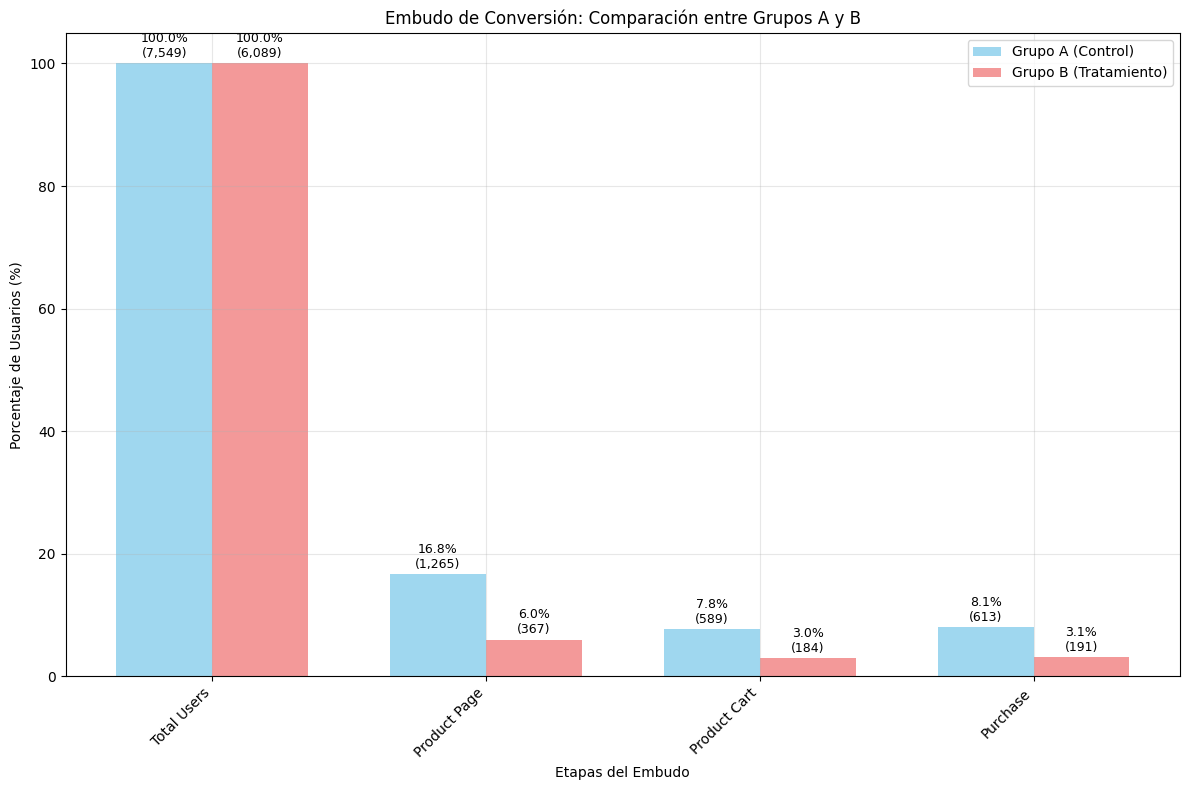

In [64]:
funnel_data = {
    'Grupo A': {
        'Total Users': 7549,
        'Product Page': 1265,
        'Product Cart': 589, 
        'Purchase': 613
    },
    'Grupo B': {
        'Total Users': 6089,
        'Product Page': 367,
        'Product Cart': 184,
        'Purchase': 191
    }
}

# Calcular tasas de conversión
stages = ['Total Users', 'Product Page', 'Product Cart', 'Purchase']
group_a_values = [funnel_data['Grupo A'][stage] for stage in stages]
group_b_values = [funnel_data['Grupo B'][stage] for stage in stages]

# Calcular porcentajes
group_a_pct = [100, 
               (group_a_values[1]/group_a_values[0])*100,
               (group_a_values[2]/group_a_values[0])*100,
               (group_a_values[3]/group_a_values[0])*100]

group_b_pct = [100,
               (group_b_values[1]/group_b_values[0])*100,
               (group_b_values[2]/group_b_values[0])*100,
               (group_b_values[3]/group_b_values[0])*100]

# Crear el gráfico de embudo
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(stages))
width = 0.35

bars1 = ax.bar(x - width/2, group_a_pct, width, label='Grupo A (Control)', 
               color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, group_b_pct, width, label='Grupo B (Tratamiento)', 
               color='lightcoral', alpha=0.8)

# Personalizar el gráfico
ax.set_xlabel('Etapas del Embudo')
ax.set_ylabel('Porcentaje de Usuarios (%)')
ax.set_title('Embudo de Conversión: Comparación entre Grupos A y B')
ax.set_xticks(x)
ax.set_xticklabels(stages, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Agregar valores en las barras
def add_value_labels(bars, values, users):
    for bar, pct, user_count in zip(bars, values, users):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{pct:.1f}%\n({user_count:,})',
                ha='center', va='bottom', fontsize=9)

add_value_labels(bars1, group_a_pct, group_a_values)
add_value_labels(bars2, group_b_pct, group_b_values)

plt.tight_layout()
plt.show()

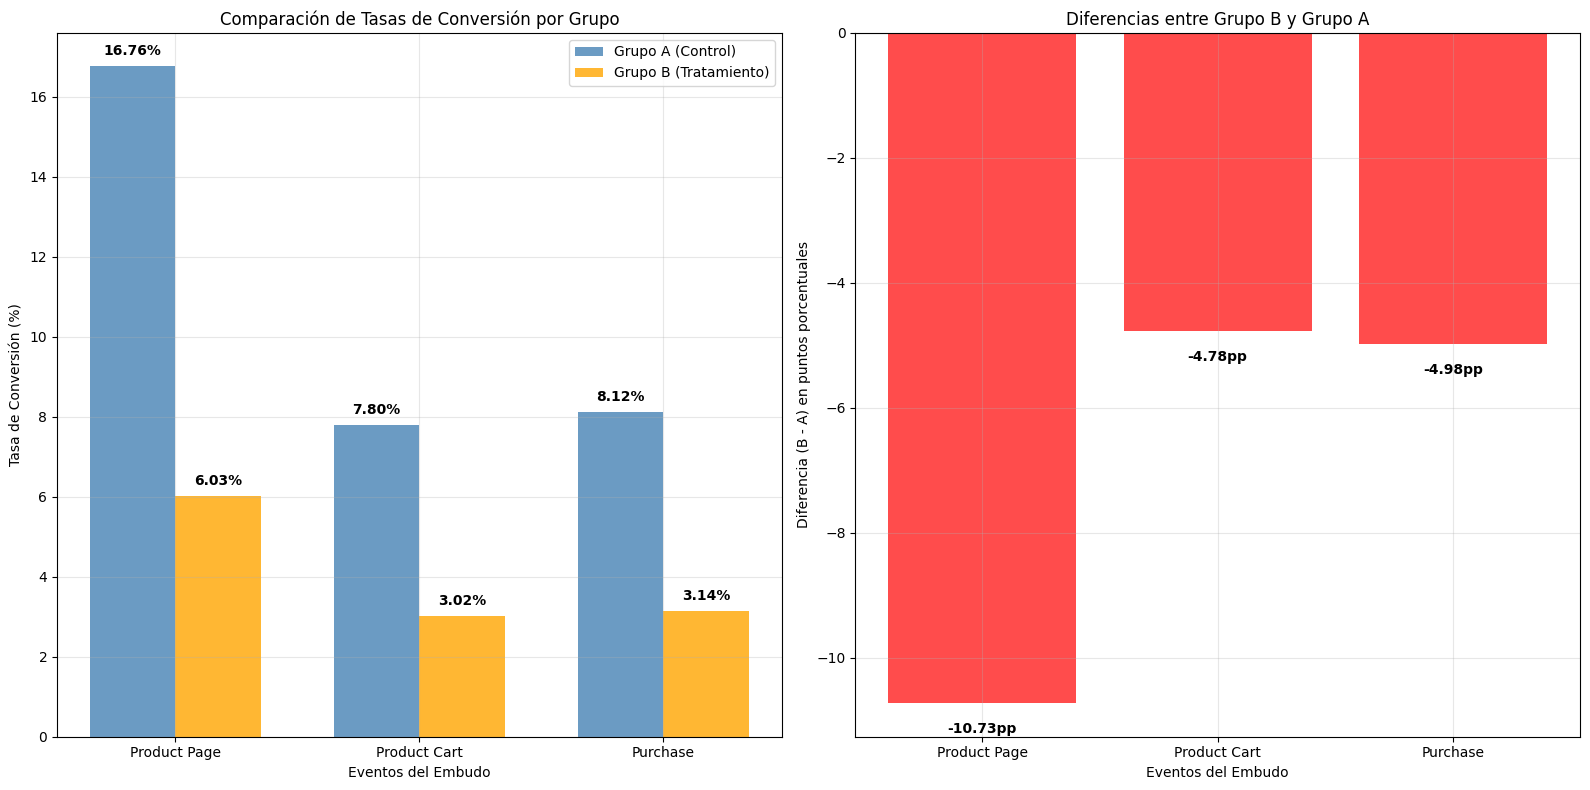

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

events = ['Product Page', 'Product Cart', 'Purchase']
group_a_rates = [16.76, 7.80, 8.12]
group_b_rates = [6.03, 3.02, 3.14]
differences = [b - a for a, b in zip(group_a_rates, group_b_rates)]

x = np.arange(len(events))
width = 0.35

bars1 = ax1.bar(x - width/2, group_a_rates, width, label='Grupo A (Control)', 
                color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, group_b_rates, width, label='Grupo B (Tratamiento)', 
                color='orange', alpha=0.8)

ax1.set_xlabel('Eventos del Embudo')
ax1.set_ylabel('Tasa de Conversión (%)')
ax1.set_title('Comparación de Tasas de Conversión por Grupo')
ax1.set_xticks(x)
ax1.set_xticklabels(events)
ax1.legend()
ax1.grid(True, alpha=0.3)

for bar, rate in zip(bars1, group_a_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold')

for bar, rate in zip(bars2, group_b_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold')

colors = ['red' if d < 0 else 'green' for d in differences]
bars3 = ax2.bar(events, differences, color=colors, alpha=0.7)

ax2.set_xlabel('Eventos del Embudo')
ax2.set_ylabel('Diferencia (B - A) en puntos porcentuales')
ax2.set_title('Diferencias entre Grupo B y Grupo A')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)

for bar, diff in zip(bars3, differences):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., 
             height + (0.1 if height > 0 else -0.3),
             f'{diff:+.2f}pp', ha='center', va='bottom' if height > 0 else 'top',
             fontweight='bold')

plt.tight_layout()
plt.show()

In [66]:
print("=== ANÁLISIS DE RESULTADOS ===\n")

results_comparison = {
    'product_page': {'A': 66.22, 'B': 64.44},
    'product_cart': {'A': 31.62, 'B': 32.96},
    'purchase': {'A': 34.22, 'B': 32.52}
}

for event in results_comparison:
    rate_a = results_comparison[event]['A']
    rate_b = results_comparison[event]['B']
    difference = rate_b - rate_a
    percent_change = (difference / rate_a) * 100
    
    print(f"{event.upper()}:")
    print(f"  Grupo A (Control): {rate_a:.2f}%")
    print(f"  Grupo B (Tratamiento): {rate_b:.2f}%")
    print(f"  Diferencia: {difference:+.2f} puntos porcentuales")
    print(f"  Cambio porcentual: {percent_change:+.2f}%")
    print(f"  ¿Cumple objetivo de +10%? {'✅ SÍ' if percent_change >= 10 else '❌ NO'}")
    print()

=== ANÁLISIS DE RESULTADOS ===

PRODUCT_PAGE:
  Grupo A (Control): 66.22%
  Grupo B (Tratamiento): 64.44%
  Diferencia: -1.78 puntos porcentuales
  Cambio porcentual: -2.69%
  ¿Cumple objetivo de +10%? ❌ NO

PRODUCT_CART:
  Grupo A (Control): 31.62%
  Grupo B (Tratamiento): 32.96%
  Diferencia: +1.34 puntos porcentuales
  Cambio porcentual: +4.24%
  ¿Cumple objetivo de +10%? ❌ NO

PURCHASE:
  Grupo A (Control): 34.22%
  Grupo B (Tratamiento): 32.52%
  Diferencia: -1.70 puntos porcentuales
  Cambio porcentual: -4.97%
  ¿Cumple objetivo de +10%? ❌ NO



Como podemos ver en primera instancia, el sistema de recomendación mejorado no cumplió con su objetivo de incrementar en 10 % cada etapa del embudo. Esto puede ser por otros factores, como las promociones navideñas que hubo durante la prueba o la distribución desigual o incluso las diferencias regionales en la asignación de grupos.

### Prueba z para comprobar la diferencia estadística entre las proporciones.

In [60]:
def z_test_proportions(x1, n1, x2, n2, alpha=0.05):
    """
    Realiza una prueba z de dos colas para diferencia de proporciones
    x1, x2: número de éxitos en cada grupo
    n1, n2: tamaño de muestra de cada grupo
    """
    # Calcular proporciones
    p1 = x1 / n1
    p2 = x2 / n2

    # Proporción combinada
    p_combined = (x1 + x2) / (n1 + n2)

    # Error estándar
    se = np.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    # Estadístico z
    z_stat = (p2 - p1) / se

    # Valor p (prueba de dos colas)
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    # Valor crítico
    z_critical = norm.ppf(1 - alpha/2)

    return {
        'p1': p1,
        'p2': p2,
        'z_stat': z_stat,
        'p_value': p_value,
        'z_critical': z_critical,
        'is_significant': abs(z_stat) > z_critical,
        'difference': p2 - p1
    }

n_A = 7549  
n_B = 6089  

conversion_data = {
    'product_page': {'A': 4999, 'B': 3924},
    'product_cart': {'A': 2387, 'B': 2007},
    'purchase': {'A': 2583, 'B': 1980}
}

print("=== PRUEBAS Z PARA DIFERENCIAS DE PROPORCIONES ===\n")

for event in conversion_data:
    x_A = conversion_data[event]['A']
    x_B = conversion_data[event]['B']

    result = z_test_proportions(x_A, n_A, x_B, n_B)

    print(f"📊 {event.upper()}:")
    print(f"   Proporción A: {result['p1']:.4f} ({result['p1']*100:.2f}%)")
    print(f"   Proporción B: {result['p2']:.4f} ({result['p2']*100:.2f}%)")
    print(f"   Diferencia: {result['difference']:+.4f} ({result['difference']*100:+.2f} puntos porcentuales)")
    print(f"   Estadístico z: {result['z_stat']:.4f}")
    print(f"   Valor p: {result['p_value']:.6f}")
    print(f"   Valor crítico (α=0.05): ±{result['z_critical']:.4f}")
    print(f"   ¿Significativo? {'✅ SÍ' if result['is_significant'] else '❌ NO'}")

=== PRUEBAS Z PARA DIFERENCIAS DE PROPORCIONES ===

📊 PRODUCT_PAGE:
   Proporción A: 0.6622 (66.22%)
   Proporción B: 0.6444 (64.44%)
   Diferencia: -0.0178 (-1.78 puntos porcentuales)
   Estadístico z: -2.1686
   Valor p: 0.030109
   Valor crítico (α=0.05): ±1.9600
   ¿Significativo? ✅ SÍ
📊 PRODUCT_CART:
   Proporción A: 0.3162 (31.62%)
   Proporción B: 0.3296 (32.96%)
   Diferencia: +0.0134 (+1.34 puntos porcentuales)
   Estadístico z: 1.6659
   Valor p: 0.095725
   Valor crítico (α=0.05): ±1.9600
   ¿Significativo? ❌ NO
📊 PURCHASE:
   Proporción A: 0.3422 (34.22%)
   Proporción B: 0.3252 (32.52%)
   Diferencia: -0.0170 (-1.70 puntos porcentuales)
   Estadístico z: -2.0902
   Valor p: 0.036601
   Valor crítico (α=0.05): ±1.9600
   ¿Significativo? ✅ SÍ


Después de realizar la prueba, podemos ver que hay datos significativos, como por ejemplo que en product_page tiene una conversión significativamente menor por 1.78 puntos; esto es algo negativo para la prueba. Esto mismo pasa en purchase; solamente la parte de product_cart no tiene nada significativo, ya que esta tiene 1.34 puntos a favor.

<div class="alert alert-block alert-success">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

Gran trabajo complementando con el calculo de la z-score y con el desarrollo de la prueba de hipótesis. Ya solamente para terminar de complementar el análisis puedes desarrollar algunas gráficas para mostrar el embudo de usuarios entre etapas


## 4 Conclusión.

Después de realizar una investigación en los datos de la prueba A/B de intentar implementar el sistema mejorado con la meta de aumentar en cada etapa del embudo un 10%, podemos ver que los resultados nos son mu favorable para nosotros, ya que por el contrario hubo un resultado significativamente peor en dos partes del embudo con una perdida significativa (Product_page: -2.69% (significativamente peor) y Purchase: -4.97% (significativamente peor)) solamente Product_cart: +4.24% (mejora, pero no significativa estadísticamente) fue favorable, pero aun así no cumplió con la expectativa de la prueba como ya mencionamos antes esto puede deberse a factores ya mencionados como el periodo navideño la distribución desigual o la las difénicas regionales.